In [1]:
# ============================================================
# JEPX スポット価格・需要・PV分析
# 東京エリア vs 九州エリア
# 2025年 30分データ（17,520コマ）
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


# ============================================================
# 0. 基本設定
# ============================================================
FILE_PATH = "データ_Spot価格_需要_PV.xlsx"
SHEET_NAME = "data"
plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# ============================================================
# 1. Excelデータの読み込み
# ============================================================
raw = pd.read_excel(
    FILE_PATH,
    sheet_name=SHEET_NAME,
    header=None
)

print("元データ shape:", raw.shape)
print(raw.head())

元データ shape: (17522, 13)
                    0     1    2    3    4    5    6                      7   \
0                  NaN   NaN  NaN  NaN  NaN  NaN  NaN  JEPXスポット市場価格\n（円/kWh）   
1                 日付時刻     年    月    日   時間    分   曜日                     東京   
2  2025-01-01 00:00:00  2025    1    1    0    0    水                  13.51   
3  2025-01-01 00:30:00  2025    1    1    0   30    水                     13   
4  2025-01-01 01:00:00  2025    1    1    1    0    水                  12.42   

      8         9     10           11   12  
0    NaN  需要\n（MW）   NaN  PV発電量\n(MW)  NaN  
1     九州        東京    九州           東京   九州  
2  10.45     26436  9214            0    0  
3  11.12     26436  9214            0    0  
4  10.82     25163  9111            0    0  


In [3]:
# ============================================================
# 2. データ整形
# ============================================================
df = raw.iloc[2:, :13].copy()
df.columns = [
    "datetime",
    "year",
    "month",
    "day",
    "hour",
    "minute",
    "weekday",
    "price_tokyo",
    "price_kyushu",
    "demand_tokyo",
    "demand_kyushu",
    "pv_tokyo",
    "pv_kyushu"]

df["datetime"] = pd.to_datetime(df["datetime"])
numeric_cols = [
    "year",
    "month",
    "day",
    "hour",
    "minute",
    "price_tokyo",
    "price_kyushu",
    "demand_tokyo",
    "demand_kyushu",
    "pv_tokyo",
    "pv_kyushu"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 行数確認
print("\nデータ件数:", len(df))
print(df.head())


データ件数: 17520
             datetime  year  month  day  hour  minute weekday  price_tokyo  \
2 2025-01-01 00:00:00  2025      1    1     0       0       水        13.51   
3 2025-01-01 00:30:00  2025      1    1     0      30       水        13.00   
4 2025-01-01 01:00:00  2025      1    1     1       0       水        12.42   
5 2025-01-01 01:30:00  2025      1    1     1      30       水        13.03   
6 2025-01-01 02:00:00  2025      1    1     2       0       水        12.42   

   price_kyushu  demand_tokyo  demand_kyushu  pv_tokyo  pv_kyushu  
2         10.45         26436           9214         0          0  
3         11.12         26436           9214         0          0  
4         10.82         25163           9111         0          0  
5         10.45         25163           9111         0          0  
6         10.60         24587           9386         0          0  


In [4]:
# ============================================================
# 3. 派生変数
# ============================================================

# -------------------------
# Net Demand = 需要 - PV発電量
# -------------------------
df["net_tokyo"] = df["demand_tokyo"] - df["pv_tokyo"]
df["net_kyushu"] = df["demand_kyushu"] - df["pv_kyushu"]

# -------------------------
# PV浸透率 = PV発電量 / 需要
# -------------------------
df["pv_ratio_tokyo"] = df["pv_tokyo"] / df["demand_tokyo"]
df["pv_ratio_kyushu"] = df["pv_kyushu"] / df["demand_kyushu"]

# -------------------------
# 0.01円/kWhフラグ
# -------------------------
df["low_tokyo"] = np.isclose(df["price_tokyo"], 0.01)
df["low_kyushu"] = np.isclose(df["price_kyushu"], 0.01)

# -------------------------
# 土日フラグ
# -------------------------
df["weekend"] = df["weekday"].isin(["土", "日"])

In [5]:
# ============================================================
# 4. 基本統計量
# ============================================================
def basic_stats(area):

    price = df[f"price_{area}"]
    demand = df[f"demand_{area}"]
    pv = df[f"pv_{area}"]
    net = df[f"net_{area}"]

    result = {
        "price_mean": price.mean(),
        "price_min": price.min(),
        "price_max": price.max(),

        "demand_mean": demand.mean(),
        "demand_min": demand.min(),
        "demand_max": demand.max(),

        "pv_mean": pv.mean(),
        "pv_min": pv.min(),
        "pv_max": pv.max(),

        "net_mean": net.mean(),
        "net_min": net.min(),
        "net_max": net.max(),
    }
    return result

tokyo_stats = basic_stats("tokyo")
kyushu_stats = basic_stats("kyushu")


print("\n==============================")
print("基本統計量")
print("==============================")


for area_name, stats in [
    ("東京", tokyo_stats),
    ("九州", kyushu_stats)]:

    print(f"\n--- {area_name} ---")
    print(
        "スポット価格 平均:",
        round(stats["price_mean"], 2))

    print(
        "スポット価格 範囲:",
        stats["price_min"],
        "～",
        stats["price_max"])

    print(
        "需要 平均:",
        round(stats["demand_mean"]))

    print(
        "需要 範囲:",
        stats["demand_min"],
        "～",
        stats["demand_max"])

    print(
        "PV 平均:",
        round(stats["pv_mean"]))

    print(
        "PV 範囲:",
        stats["pv_min"],
        "～",
        stats["pv_max"])

    print(
        "Net Demand 平均:",
        round(stats["net_mean"]))

    print(
        "Net Demand 範囲:",
        stats["net_min"],
        "～",
        stats["net_max"])


基本統計量

--- 東京 ---
スポット価格 平均: 12.64
スポット価格 範囲: 0.01 ～ 40.01
需要 平均: 32170
需要 範囲: 18525 ～ 57538
PV 平均: 2969
PV 範囲: 0 ～ 16540
Net Demand 平均: 29201
Net Demand 範囲: 7367 ～ 53023

--- 九州 ---
スポット価格 平均: 10.12
スポット価格 範囲: 0.01 ～ 45.01
需要 平均: 10023
需要 範囲: 6182 ～ 15736
PV 平均: 1768
PV 範囲: 0 ～ 10394
Net Demand 平均: 8255
Net Demand 範囲: -2961 ～ 15501


In [6]:
# ============================================================
# 5. 単純相関分析
# ============================================================
def correlation_results(area):
    price = df[f"price_{area}"]
    demand_corr = price.corr(df[f"demand_{area}"])
    pv_corr = price.corr(df[f"pv_{area}"])
    net_corr = price.corr(df[f"net_{area}"])
    return demand_corr, pv_corr, net_corr

tokyo_corr = correlation_results("tokyo")
kyushu_corr = correlation_results("kyushu")

print("\n==============================")
print("相関係数")
print("==============================")

print("\n東京")
print("価格 × 需要:", round(tokyo_corr[0], 3))
print("価格 × PV:", round(tokyo_corr[1], 3))
print("価格 × Net Demand:", round(tokyo_corr[2], 3))

print("\n九州")
print("価格 × 需要:",round(kyushu_corr[0], 3))
print("価格 × PV:", round(kyushu_corr[1], 3))
print("価格 × Net Demand:", round(kyushu_corr[2], 3))


相関係数

東京
価格 × 需要: 0.528
価格 × PV: -0.334
価格 × Net Demand: 0.759

九州
価格 × 需要: 0.468
価格 × PV: -0.534
価格 × Net Demand: 0.814


In [7]:
# ============================================================
# 6. 時間帯別平均
# ============================================================
hourly = df.groupby("hour").agg({
    "price_tokyo": "mean",
    "price_kyushu": "mean",

    "pv_ratio_tokyo": "mean",
    "pv_ratio_kyushu": "mean",

    "demand_tokyo": "mean",
    "demand_kyushu": "mean",

    "pv_tokyo": "mean",
    "pv_kyushu": "mean"})


print("\n==============================")
print("12時の平均")
print("==============================")

print("東京価格:", round(hourly.loc[12, "price_tokyo"], 2))
print("九州価格:", round(hourly.loc[12, "price_kyushu"], 2))
print("東京PV浸透率:", round(hourly.loc[12, "pv_ratio_tokyo"] * 100, 1), "%")
print("九州PV浸透率:", round(hourly.loc[12, "pv_ratio_kyushu"] * 100, 1), "%")

print("\n==============================")
print("18時の平均")
print("==============================")

print("東京価格:", round(hourly.loc[18, "price_tokyo"], 2))
print("九州価格:", round(hourly.loc[18, "price_kyushu"], 2))


12時の平均
東京価格: 9.86
九州価格: 5.13
東京PV浸透率: 29.3 %
九州PV浸透率: 58.8 %

18時の平均
東京価格: 16.39
九州価格: 15.51


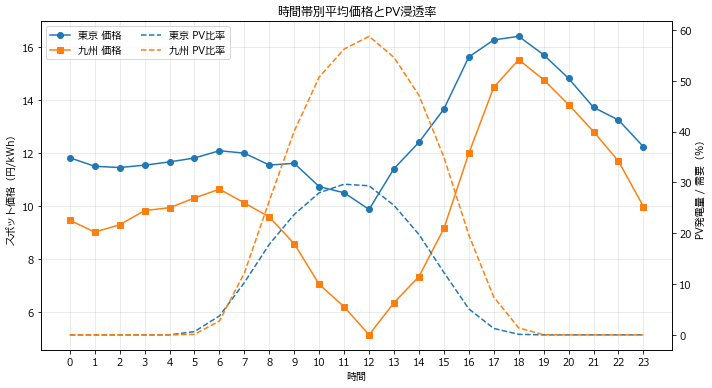

In [8]:
# ============================================================
# 7. 図1
# 時間帯別平均価格とPV浸透率
# ============================================================
fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax2 = ax1.twinx()

# 価格
ax1.plot(
    hourly.index,
    hourly["price_tokyo"],
    marker="o",
    label="東京 価格")

ax1.plot(
    hourly.index,
    hourly["price_kyushu"],
    marker="s",
    label="九州 価格")

# PV浸透率
ax2.plot(
    hourly.index,
    hourly["pv_ratio_tokyo"] * 100,
    linestyle="--",
    label="東京 PV比率")

ax2.plot(
    hourly.index,
    hourly["pv_ratio_kyushu"] * 100,
    linestyle="--",
    label="九州 PV比率")

ax1.set_title("時間帯別平均価格とPV浸透率")
ax1.set_xlabel("時間")
ax1.set_ylabel("スポット価格（円/kWh）")
ax2.set_ylabel("PV発電量 / 需要（%）")
ax1.set_xticks(range(24))
ax1.grid(alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    ncol=2)
plt.tight_layout()
plt.savefig(
    "01_hourly_price_pv.png",
    dpi=200,
    bbox_inches="tight")
plt.show()

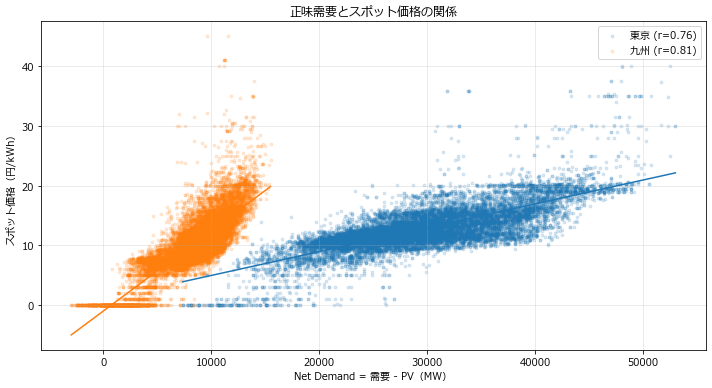

In [9]:
# ============================================================
# 8. 図2
# Net Demandと価格の散布図
# ============================================================
plt.figure(figsize=(10, 5.5))

# 東京
plt.scatter(
    df["net_tokyo"],
    df["price_tokyo"],
    s=8,
    alpha=0.15,
    label=f"東京 (r={tokyo_corr[2]:.2f})")

# 九州
plt.scatter(
    df["net_kyushu"],
    df["price_kyushu"],
    s=8,
    alpha=0.15,
    label=f"九州 (r={kyushu_corr[2]:.2f})")

# 東京回帰直線
coef_tokyo = np.polyfit(
    df["net_tokyo"],
    df["price_tokyo"],
    1)

x_tokyo = np.linspace(
    df["net_tokyo"].min(),
    df["net_tokyo"].max(),
    200)

y_tokyo = coef_tokyo[0] * x_tokyo + coef_tokyo[1]
plt.plot(x_tokyo, y_tokyo)

# 九州回帰直線
coef_kyushu = np.polyfit(
    df["net_kyushu"],
    df["price_kyushu"],
    1)

x_kyushu = np.linspace(
    df["net_kyushu"].min(),
    df["net_kyushu"].max(),
    200)

y_kyushu = coef_kyushu[0] * x_kyushu + coef_kyushu[1]

plt.plot(
    x_kyushu,
    y_kyushu)

plt.title("正味需要とスポット価格の関係")
plt.xlabel("Net Demand = 需要 - PV（MW）")
plt.ylabel("スポット価格（円/kWh）")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    "02_net_demand_scatter.png",
    dpi=200,
    bbox_inches="tight")
plt.show()

In [10]:
# ============================================================
# 9. 標準化重回帰分析
# ============================================================
def standardized_regression(area):
    X = df[[f"demand_{area}",f"pv_{area}"]].copy()
    y = df[f"price_{area}"].copy()

    # 説明変数の標準化
    scaler_X = StandardScaler()
    X_std = scaler_X.fit_transform(X)

    # 被説明変数も標準化
    scaler_y = StandardScaler()
    y_std = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()
    
    # 回帰
    model = LinearRegression()
    model.fit(X_std, y_std)

    beta_demand = model.coef_[0]
    beta_pv = model.coef_[1]

    r2 = model.score(X_std, y_std)
    return(beta_demand,beta_pv, r2)

tokyo_reg = standardized_regression("tokyo")
kyushu_reg = standardized_regression("kyushu")


print("\n==============================")
print("標準化重回帰分析")
print("==============================")

print("\n東京")
print(
    "需要 β:",
    round(tokyo_reg[0], 3))
print(
    "PV β:",
    round(tokyo_reg[1], 3))
print(
    "R²:",
    round(tokyo_reg[2], 3))

print("\n九州")
print(
    "需要 β:",
    round(kyushu_reg[0], 3)
)
print(
    "PV β:",
    round(kyushu_reg[1], 3))
print(
    "R²:",
    round(kyushu_reg[2], 3))


標準化重回帰分析

東京
需要 β: 0.746
PV β: -0.604
R²: 0.596

九州
需要 β: 0.646
PV β: -0.698
R²: 0.675


In [11]:
# ============================================================
# 10. 0.01円/kWh 発生回数・発生率
# ============================================================
for area, name in [
    ("tokyo", "東京"),
    ("kyushu", "九州")]:

    count = df[f"low_{area}"].sum()
    rate = df[f"low_{area}"].mean()
    print(f"\n{name}")
    print("0.01円発生回数:", count)
    print("0.01円発生率:", round(rate * 100, 2), "%")


# ============================================================
# 11. Net Demand < 0
# ============================================================
for area, name in [
    ("tokyo", "東京"),
    ("kyushu", "九州")]:

    negative_mask = (df[f"net_{area}"] < 0)

    negative_count = (negative_mask.sum())

    low_count = df.loc[
        negative_mask,
        f"low_{area}"].sum()

    print(f"\n{name}")
    print("Net Demand < 0 コマ:", negative_count)
    print("そのうち0.01円:", low_count)

    if negative_count > 0:
        print("発生率:", round(low_count / negative_count * 100, 1), "%")

# ============================================================
# 12. 0.01円発生時の平均PV浸透率
# ============================================================
for area, name in [
    ("tokyo", "東京"),
    ("kyushu", "九州")]:

    avg_ratio = df.loc[
        df[f"low_{area}"],
        f"pv_ratio_{area}"].mean()

    print(
        f"{name} "
        "0.01円発生時の平均PV浸透率:",
        round(avg_ratio * 100, 1), "%")

# ============================================================
# 13. 月別0.01円発生回数
# ============================================================
monthly_tokyo = df.groupby("month")["low_tokyo"].sum()
monthly_kyushu = df.groupby("month")["low_kyushu"].sum()

print("\n==============================")
print("月別0.01円発生回数")
print("==============================")

monthly_result = pd.DataFrame({
    "東京": monthly_tokyo,
    "九州": monthly_kyushu
})
print(monthly_result)


東京
0.01円発生回数: 112
0.01円発生率: 0.64 %

九州
0.01円発生回数: 995
0.01円発生率: 5.68 %

東京
Net Demand < 0 コマ: 0
そのうち0.01円: 0

九州
Net Demand < 0 コマ: 214
そのうち0.01円: 214
発生率: 100.0 %
東京 0.01円発生時の平均PV浸透率: 54.2 %
九州 0.01円発生時の平均PV浸透率: 84.3 %

月別0.01円発生回数
       東京   九州
month         
1       0   71
2       0   56
3      41  171
4      35  252
5      36  229
6       0   89
7       0    0
8       0    0
9       0    0
10      0   31
11      0   86
12      0   10


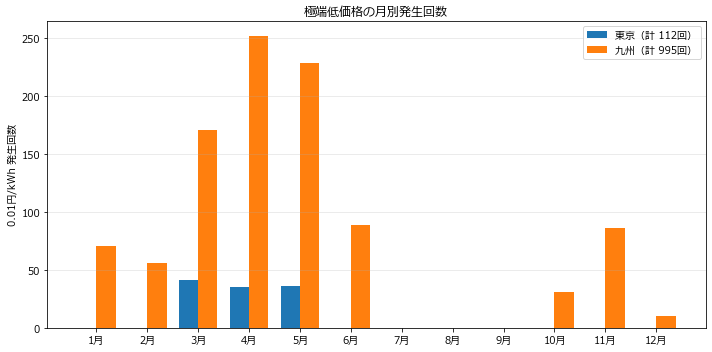

In [12]:
# ============================================================
# 14. 図3
# 月別0.01円発生回数
# ============================================================
months = np.arange(1,13)
x = np.arange(12)
width = 0.38

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    monthly_tokyo.values,
    width=width,
    label=f"東京（計 {df['low_tokyo'].sum()}回）")

plt.bar(
    x + width / 2,
    monthly_kyushu.values,
    width=width,
    label=f"九州（計 {df['low_kyushu'].sum()}回）")

plt.xticks(
    x,
    [
        f"{m}月"
        for m in months
    ])

plt.ylabel("0.01円/kWh 発生回数")

plt.title("極端低価格の月別発生回数")

plt.grid(axis="y", alpha=0.3)

plt.legend()
plt.tight_layout()
plt.savefig(
    "03_low_price_monthly.png",
    dpi=200,
    bbox_inches="tight")

plt.show()

In [13]:
# ============================================================
# 15. PV浸透率閾値分析
# ============================================================
thresholds = [
    0.20,
    0.40,
    0.50,
    0.60,
    0.80,
    1.00]

def pv_threshold_analysis(area):
    results = []
    for threshold in thresholds:
        mask = df[f"pv_ratio_{area}"] >= threshold
        total_count = mask.sum()
        low_count = df.loc[
            mask,
            f"low_{area}"].sum()

        if total_count > 0:
            low_rate = low_count / total_count

        else:
            low_rate = np.nan

        results.append({
            "threshold": threshold,
            "threshold_pct":
                threshold * 100,
            "count":
                total_count,
            "low_count":
                low_count,
            "low_rate":
                low_rate,
            "low_rate_pct":
                low_rate * 100
                if not np.isnan(low_rate)
                else np.nan })

    return pd.DataFrame(results)


tokyo_threshold = pv_threshold_analysis("tokyo")
kyushu_threshold = pv_threshold_analysis("kyushu")

print("\n==============================")
print("PV浸透率閾値分析 東京")
print("==============================")
print(tokyo_threshold)
print("\n==============================")
print("PV浸透率閾値分析 九州")
print("==============================")
print(kyushu_threshold)

# ============================================================
# 16. 50%以上の詳細
# ============================================================
for area, name in [
    ("tokyo", "東京"),
    ("kyushu", "九州")
]:
    mask = df[f"pv_ratio_{area}"] >= 0.50
    total = mask.sum()
    low = df.loc[
        mask,
        f"low_{area}"].sum()
    rate = low / total
    
    print(f"\n{name} PV浸透率50%以上")
    print("全コマ:", total)
    print("0.01円:", low)
    print("発生率:", round(rate * 100, 1), "%")

# ============================================================
# 17. 九州80%以上・100%以上
# ============================================================
for threshold in [
    0.80,
    1.00
]:
    mask = df["pv_ratio_kyushu"] >= threshold
    total = mask.sum()
    low = df.loc[mask, "low_kyushu"].sum()
    rate = low / total

    print(
        f"\n九州 PV浸透率"
        f"{threshold*100:.0f}%以上")

    print("コマ数:", total)
    print("0.01円:", low)
    print("発生率:", round(rate * 100, 1),"%")


PV浸透率閾値分析 東京
   threshold  threshold_pct  count  low_count  low_rate  low_rate_pct
0        0.2           20.0   3536        111  0.031391      3.139140
1        0.4           40.0    600        109  0.181667     18.166667
2        0.5           50.0    158         76  0.481013     48.101266
3        0.6           60.0     36         34  0.944444     94.444444
4        0.8           80.0      0          0       NaN           NaN
5        1.0          100.0      0          0       NaN           NaN

PV浸透率閾値分析 九州
   threshold  threshold_pct  count  low_count  low_rate  low_rate_pct
0        0.2           20.0   5456        993  0.182001     18.200147
1        0.4           40.0   3356        984  0.293206     29.320620
2        0.5           50.0   2356        959  0.407046     40.704584
3        0.6           60.0   1504        885  0.588431     58.843085
4        0.8           80.0    574        554  0.965157     96.515679
5        1.0          100.0    214        214  1.000000    100

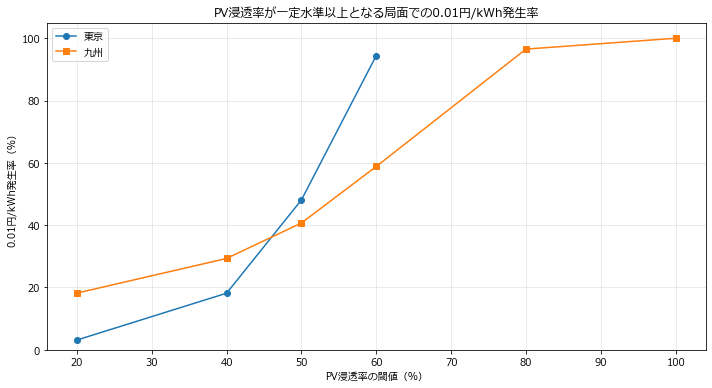

In [14]:
# ============================================================
# 18. 図4
# PV浸透率が一定水準以上となる局面での
# 0.01円/kWh発生率
# ============================================================
plt.figure(figsize=(10, 5.5))

# 東京
plt.plot(
    tokyo_threshold["threshold_pct"],
    tokyo_threshold["low_rate_pct"],
    marker="o",
    label="東京")

# 九州
plt.plot(
    kyushu_threshold["threshold_pct"],
    kyushu_threshold["low_rate_pct"],
    marker="s",
    label="九州")

plt.title("PV浸透率が一定水準以上となる局面での0.01円/kWh発生率")
plt.xlabel("PV浸透率の閾値（%）")
plt.ylabel("0.01円/kWh発生率（%）")
plt.ylim(0,105)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    "04_pv_threshold_lowprice.png",
    dpi=200,
    bbox_inches="tight")
plt.show()


平日・土日 0.01円発生率
東京 平日: 0.38 %
東京 土日: 1.3 %
九州 平日: 4.75 %
九州 土日: 8.01 %


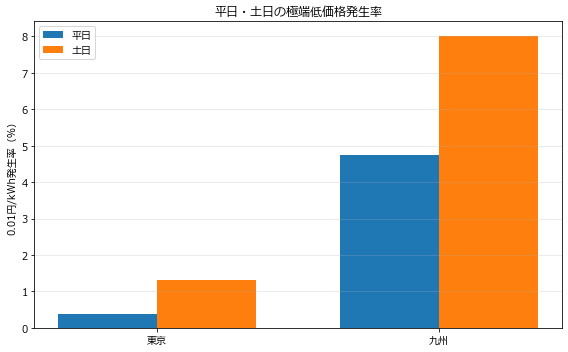

In [15]:
# ============================================================
# 19. 平日・土日の0.01円発生率
# ============================================================
def weekday_weekend_analysis(area):
    weekday_mask = ~df["weekend"]
    weekend_mask = df["weekend"]
    weekday_rate = df.loc[weekday_mask, f"low_{area}"].mean()
    weekend_rate = df.loc[weekend_mask, f"low_{area}"].mean()
    return (weekday_rate, weekend_rate)


tokyo_week = weekday_weekend_analysis("tokyo")
kyushu_week = weekday_weekend_analysis("kyushu")

print("\n==============================")
print("平日・土日 0.01円発生率")
print("==============================")
print("東京 平日:",round(tokyo_week[0] * 100, 2), "%")
print("東京 土日:", round(tokyo_week[1] * 100, 2), "%")
print("九州 平日:",round(kyushu_week[0] * 100, 2), "%")
print("九州 土日:", round(kyushu_week[1] * 100, 2), "%")


# ============================================================
# 20. 図5
# 平日・土日の極端低価格発生率
# ============================================================
x = np.arange(2)
width = 0.35
weekday_rates = [tokyo_week[0] * 100, kyushu_week[0] * 100]
weekend_rates = [tokyo_week[1] * 100, kyushu_week[1] * 100]

plt.figure(figsize=(8, 5))
plt.bar(
    x - width / 2,
    weekday_rates,
    width=width,
    label="平日")
plt.bar(
    x + width / 2,
    weekend_rates,
    width=width,
    label="土日")

plt.xticks(x,["東京","九州"])
plt.ylabel("0.01円/kWh発生率（%）")
plt.title("平日・土日の極端低価格発生率")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    "05_weekend_low_price.png",
    dpi=200,
    bbox_inches="tight")
plt.show()

In [16]:
# ============================================================
# 21. 最終確認用：Wordに使った主要数値をまとめて表示
# ============================================================
print("\n\n==========================================")
print("Word記載用 主要結果まとめ")
print("==========================================")

print("\n【基本統計】")
print("東京価格平均:", round(df["price_tokyo"].mean(), 2))
print("九州価格平均:", round(df["price_kyushu"].mean(), 2))
print("東京需要平均:", round(df["demand_tokyo"].mean()))
print("九州需要平均:", round(df["demand_kyushu"].mean()))
print("東京PV平均:", round(df["pv_tokyo"].mean()))
print("九州PV平均:", round(df["pv_kyushu"].mean()))
print("東京Net Demand平均:", round(df["net_tokyo"].mean()))
print("九州Net Demand平均:", round(df["net_kyushu"].mean()))

print("\n【相関】")
print("東京 価格×需要:", round(tokyo_corr[0], 2))
print("九州 価格×需要:", round(kyushu_corr[0], 2))
print("東京 価格×PV:", round(tokyo_corr[1], 2))
print("九州 価格×PV:", round(kyushu_corr[1], 2))
print("東京 価格×Net Demand:", round(tokyo_corr[2], 2))
print("九州 価格×Net Demand:", round(kyushu_corr[2], 2))

print("\n【12時】")
print("東京PV浸透率:", round(hourly.loc[12, "pv_ratio_tokyo"] * 100, 1), "%")
print("九州PV浸透率:", round(hourly.loc[12, "pv_ratio_kyushu"] * 100, 1), "%")
print("東京価格:", round(hourly.loc[12,"price_tokyo"], 2))
print("九州価格:", round(hourly.loc[12, "price_kyushu"], 2))

print("\n【18時価格】")
print("東京:", round(hourly.loc[18, "price_tokyo"], 2))
print("九州:", round(hourly.loc[18, "price_kyushu"],2))

print("\n【重回帰】")
print("東京 β需要:", round(tokyo_reg[0], 2))
print("東京 βPV:", round(tokyo_reg[1], 2))
print("東京 R²:", round(tokyo_reg[2], 2))
print("九州 β需要:", round(kyushu_reg[0], 2))
print("九州 βPV:", round(kyushu_reg[1], 2))
print("九州 R²:", round(kyushu_reg[2], 2))

print("\n【0.01円】")
print("東京:", df["low_tokyo"].sum(), "回 /", round(df["low_tokyo"].mean() * 100, 2), "%")
print("九州:", df["low_kyushu"].sum(), "回 /", round(df["low_kyushu"].mean() * 100, 2), "%")

print("\n【Net Demand < 0】")
print("東京:",(df["net_tokyo"] < 0).sum())
print("九州:", (df["net_kyushu"] < 0).sum())

print("\n【PV50%以上】")
for area, name in [("tokyo", "東京"), ("kyushu", "九州")]:
    mask = df[f"pv_ratio_{area}"] >= 0.50
    print(
        name,
        "コマ数:",
        mask.sum(),
        "0.01円:",
        df.loc[mask, f"low_{area}"].sum(),
        "発生率:",
        round(df.loc[mask, f"low_{area}"].mean() * 100, 1), "%")


print("\n【九州 PV80%以上】")
mask80 = df["pv_ratio_kyushu"] >= 0.80
print("コマ数:", mask80.sum())
print("0.01円:", df.loc[mask80,"low_kyushu"].sum())
print("発生率:", round(df.loc[mask80, "low_kyushu"].mean() * 100, 1),"%")

print("\n【九州 PV100%以上】")
mask100 = df["pv_ratio_kyushu"] >= 1.00
print("コマ数:", mask100.sum())
print("0.01円:", df.loc[mask100, "low_kyushu"].sum())
print("発生率:",round(df.loc[mask100,"low_kyushu"].mean() * 100, 1),"%")



Word記載用 主要結果まとめ

【基本統計】
東京価格平均: 12.64
九州価格平均: 10.12
東京需要平均: 32170
九州需要平均: 10023
東京PV平均: 2969
九州PV平均: 1768
東京Net Demand平均: 29201
九州Net Demand平均: 8255

【相関】
東京 価格×需要: 0.53
九州 価格×需要: 0.47
東京 価格×PV: -0.33
九州 価格×PV: -0.53
東京 価格×Net Demand: 0.76
九州 価格×Net Demand: 0.81

【12時】
東京PV浸透率: 29.3 %
九州PV浸透率: 58.8 %
東京価格: 9.86
九州価格: 5.13

【18時価格】
東京: 16.39
九州: 15.51

【重回帰】
東京 β需要: 0.75
東京 βPV: -0.6
東京 R²: 0.6
九州 β需要: 0.65
九州 βPV: -0.7
九州 R²: 0.67

【0.01円】
東京: 112 回 / 0.64 %
九州: 995 回 / 5.68 %

【Net Demand < 0】
東京: 0
九州: 214

【PV50%以上】
東京 コマ数: 158 0.01円: 76 発生率: 48.1 %
九州 コマ数: 2356 0.01円: 959 発生率: 40.7 %

【九州 PV80%以上】
コマ数: 574
0.01円: 554
発生率: 96.5 %

【九州 PV100%以上】
コマ数: 214
0.01円: 214
発生率: 100.0 %
